# 04b. Multiclass Classifier (Leakage-safe Diagnostician)
This notebook trains and compares multiclass fault diagnosticians on fault-period rows only.

- Run-level split by a stable run key built from original faultNumber + simulationRun + source.
- Pre-fault rows are masked out of the target, but kept while rolling features are computed.
- Rolling features are computed within each full selected run before filtering to labelled fault-period rows.
- HistGradientBoosting and XGBoost are trained/evaluated on identical train/validation/test rows.
- Test evaluation is conditional on a fault already being present; end-to-end performance is handled by the binary gatekeeper.


In [1]:
import json
import time
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")


def find_project_root(start: Path) -> Path:
    for path in [start, *start.parents]:
        if (path / "data" / "processed").is_dir():
            return path
    raise FileNotFoundError("Could not find data/processed from current directory")


PROJECT_ROOT = find_project_root(Path.cwd())
DATA_DIR = PROJECT_ROOT / "data" / "processed"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR = PROJECT_ROOT / "models" / "final"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
CHAMPION_WINDOWS = [10, 20, 30, 50, 100]

TRAIN_RUNS_PER_LABEL = 50
VAL_RUNS_PER_LABEL = 20
TEST_RUNS_PER_LABEL = 20

TRAIN_PREFAULT_CUTOFF = 20
TEST_PREFAULT_CUTOFF = 160

BASE_FEATURES = [
    c
    for c in pd.read_csv(DATA_DIR / "tep_train.csv", nrows=1).columns
    if c.startswith("xmeas_") or c.startswith("xmv_")
]

print("Setup complete.")


Setup complete.


In [2]:
def prepare_multiclass_frame(df: pd.DataFrame, source_name: str, label_col: str, prefault_cutoff: int) -> pd.DataFrame:
    df = df.copy()
    if "simulationRun" not in df.columns:
        raise KeyError("Column 'simulationRun' is required for run-level splitting.")
    if "sample" not in df.columns:
        raise KeyError("Column 'sample' is required for pre-fault masking.")
    if label_col not in df.columns:
        raise KeyError(f"Column '{label_col}' is required.")

    # Keep original fault identity for run keys. The target can be masked to 0,
    # but the run must still belong to its true fault/run identity.
    df["original_fault_label"] = df[label_col].astype(int)
    df["target_fault_label"] = df["original_fault_label"]
    df.loc[df["sample"] <= prefault_cutoff, "target_fault_label"] = 0
    df["source_file"] = source_name
    df["run_key"] = (
        df["source_file"].astype(str)
        + "_fault_"
        + df["original_fault_label"].astype(str)
        + "_run_"
        + df["simulationRun"].astype(str)
    )
    return df


def split_by_run_key(df: pd.DataFrame, train_size: float, random_state: int, stratify_col: str):
    run_meta = df.drop_duplicates("run_key").set_index("run_key")
    run_keys = run_meta.index.to_numpy()
    strat_labels = run_meta.loc[run_keys, stratify_col].astype(int)
    train_keys, val_keys = train_test_split(
        run_keys,
        train_size=train_size,
        random_state=random_state,
        shuffle=True,
        stratify=strat_labels,
    )
    df_train = df[df["run_key"].isin(train_keys)].copy()
    df_val = df[df["run_key"].isin(val_keys)].copy()
    overlap = set(df_train["run_key"]) & set(df_val["run_key"])
    assert not overlap, "Leakage detected: train and validation share run_key."
    return df_train, df_val


def sample_runs_per_label(df: pd.DataFrame, runs_per_label: int, random_state: int, label_col: str):
    rng = np.random.default_rng(random_state)
    sampled = []
    run_meta = df.drop_duplicates("run_key")[["run_key", label_col]]
    for label in sorted(run_meta[label_col].unique()):
        if int(label) == 0:
            continue
        run_ids = run_meta.loc[run_meta[label_col] == label, "run_key"].to_numpy()
        n_runs = min(runs_per_label, len(run_ids))
        if n_runs == 0:
            continue
        chosen = rng.choice(run_ids, size=n_runs, replace=False)
        sampled.append(df[df["run_key"].isin(chosen)])
    return pd.concat(sampled, ignore_index=True) if sampled else df.head(0).copy()


def add_rolling_features_by_run(
    df: pd.DataFrame,
    base_feature_cols: list,
    windows: list,
    run_col: str = "run_key",
    time_col: str = "sample",
    min_periods: int = 1,
) -> pd.DataFrame:
    for col in [run_col] + list(base_feature_cols):
        if col not in df.columns:
            raise KeyError(f"Required column missing: {col}")
    df_out = df.copy()
    if time_col in df_out.columns:
        df_out = df_out.sort_values([run_col, time_col]).reset_index(drop=True)
    else:
        df_out = df_out.sort_values([run_col]).reset_index(drop=True)

    grouped = df_out.groupby(run_col, sort=False)
    new_cols = []
    for window in windows:
        roll_mean = (
            grouped[base_feature_cols]
            .rolling(window=window, min_periods=min_periods)
            .mean()
            .reset_index(level=0, drop=True)
        )
        roll_mean.columns = [f"{col}_roll_mean_{window}" for col in base_feature_cols]
        new_cols.append(roll_mean.astype("float32"))

        roll_std = (
            grouped[base_feature_cols]
            .rolling(window=window, min_periods=min_periods)
            .std()
            .reset_index(level=0, drop=True)
            .fillna(0.0)
        )
        roll_std.columns = [f"{col}_roll_std_{window}" for col in base_feature_cols]
        new_cols.append(roll_std.astype("float32"))
    return pd.concat([df_out] + new_cols, axis=1)


def get_model_feature_cols(base_feature_cols: list, windows: list) -> list:
    rolling_cols = []
    for window in windows:
        for col in base_feature_cols:
            rolling_cols.append(f"{col}_roll_mean_{window}")
            rolling_cols.append(f"{col}_roll_std_{window}")
    return list(base_feature_cols) + rolling_cols


def check_feature_columns(df: pd.DataFrame, feature_cols: list) -> None:
    missing = [c for c in feature_cols if c not in df.columns]
    if missing:
        raise KeyError(f"Missing feature columns: {missing[:10]}")
    non_numeric = [c for c in feature_cols if not pd.api.types.is_numeric_dtype(df[c])]
    if non_numeric:
        raise TypeError(f"Non-numeric feature columns found: {non_numeric[:10]}")


def check_no_leaky_features(feature_cols: list) -> None:
    suspicious = (
        "fault", "label", "target", "source", "run", "sample", "time",
        "prediction", "probability", "alarm", "health", "severity",
    )
    bad = [col for col in feature_cols if any(token in col.lower() for token in suspicious)]
    if bad:
        raise ValueError(f"Potential leakage columns in MODEL_FEATURE_COLS: {bad[:10]}")


def assert_no_run_overlap(*named_frames):
    for i, (name_a, df_a) in enumerate(named_frames):
        runs_a = set(df_a["run_key"].unique())
        for name_b, df_b in named_frames[i + 1:]:
            overlap = runs_a & set(df_b["run_key"].unique())
            assert not overlap, f"Run overlap detected between {name_a} and {name_b}."
    print("Run-level overlap check passed.")


def fault_period_only(df: pd.DataFrame) -> pd.DataFrame:
    return df[df["target_fault_label"] > 0].copy()


print("Helper functions defined.")


Helper functions defined.


In [3]:
print("Loading training data...")
train_full = pd.read_csv(DATA_DIR / "tep_train.csv")

if "label" in train_full.columns:
    label_col = "label"
elif "faultNumber" in train_full.columns:
    label_col = "faultNumber"
else:
    raise KeyError("Expected 'label' or 'faultNumber' in tep_train.csv")

train_full = prepare_multiclass_frame(
    train_full, source_name="TEP_Train", label_col=label_col, prefault_cutoff=TRAIN_PREFAULT_CUTOFF
)
fault_runs = train_full[train_full["original_fault_label"] > 0].copy()
print(f"Fault-run rows available before sampling: {len(fault_runs):,}")

print("Run-level train/validation split...")
train_runs, val_runs = split_by_run_key(
    fault_runs, train_size=0.80, random_state=RANDOM_STATE, stratify_col="original_fault_label"
)
train_runs = sample_runs_per_label(train_runs, TRAIN_RUNS_PER_LABEL, RANDOM_STATE, "original_fault_label")
val_runs = sample_runs_per_label(val_runs, VAL_RUNS_PER_LABEL, RANDOM_STATE + 1, "original_fault_label")
assert_no_run_overlap(("train", train_runs), ("validation", val_runs))

print("Engineering rolling features within full selected runs...")
train_eng_full = add_rolling_features_by_run(train_runs, BASE_FEATURES, CHAMPION_WINDOWS)
val_eng_full = add_rolling_features_by_run(val_runs, BASE_FEATURES, CHAMPION_WINDOWS)

train_eng = fault_period_only(train_eng_full)
val_eng = fault_period_only(val_eng_full)

MODEL_FEATURE_COLS = get_model_feature_cols(BASE_FEATURES, CHAMPION_WINDOWS)
check_no_leaky_features(MODEL_FEATURE_COLS)
check_feature_columns(train_eng, MODEL_FEATURE_COLS)
check_feature_columns(val_eng, MODEL_FEATURE_COLS)

X_train = train_eng[MODEL_FEATURE_COLS].to_numpy(dtype=np.float32)
y_train = train_eng["target_fault_label"].to_numpy(dtype=np.int16)
X_val = val_eng[MODEL_FEATURE_COLS].to_numpy(dtype=np.float32)
y_val = val_eng["target_fault_label"].to_numpy(dtype=np.int16)

print(f"Train fault-period rows: {X_train.shape} | labels={sorted(np.unique(y_train).tolist())}")
print(f"Val fault-period rows:   {X_val.shape} | labels={sorted(np.unique(y_val).tolist())}")


Loading training data...
Fault-run rows available before sampling: 5,000,000
Run-level train/validation split...
Run-level overlap check passed.
Engineering rolling features within full selected runs...
Train fault-period rows: (480000, 572) | labels=[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]
Val fault-period rows:   (192000, 572) | labels=[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]


In [4]:
def train_hist_gradient_boosting(X_train, y_train):
    sample_weight = compute_sample_weight(class_weight="balanced", y=y_train)
    model = HistGradientBoostingClassifier(
        max_iter=200,
        learning_rate=0.05,
        max_depth=8,
        random_state=RANDOM_STATE,
        verbose=0,
    )
    model.fit(X_train, y_train, sample_weight=sample_weight)
    return model


def train_xgboost(X_train, y_train):
    encoder = LabelEncoder()
    y_train_enc = encoder.fit_transform(y_train)
    sample_weight = compute_sample_weight(class_weight="balanced", y=y_train_enc)
    model = XGBClassifier(
        objective="multi:softprob",
        num_class=len(encoder.classes_),
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        eval_metric="mlogloss",
        tree_method="hist",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    model.fit(X_train, y_train_enc, sample_weight=sample_weight)
    return {"model": model, "encoder": encoder}


def predict_model(model_name, fitted, X):
    if model_name == "xgboost":
        pred_enc = fitted["model"].predict(X)
        return fitted["encoder"].inverse_transform(pred_enc.astype(int))
    return fitted.predict(X)


def evaluate_predictions(y_true, y_pred):
    report = classification_report(y_true, y_pred, output_dict=True, zero_division=0)
    return {
        "accuracy": report["accuracy"],
        "macro_recall": report["macro avg"]["recall"],
        "macro_f1": report["macro avg"]["f1-score"],
        "weighted_f1": report["weighted avg"]["f1-score"],
        "classification_report": report,
    }


model_specs = {
    "hist_gradient_boosting": train_hist_gradient_boosting,
    "xgboost": train_xgboost,
}

trained_models = {}
comparison_rows = []

for model_name, train_fn in model_specs.items():
    print(f"Training {model_name}...")
    t0 = time.time()
    fitted = train_fn(X_train, y_train)
    train_time = time.time() - t0
    trained_models[model_name] = fitted

    val_pred = predict_model(model_name, fitted, X_val)
    val_metrics = evaluate_predictions(y_val, val_pred)
    comparison_rows.append({
        "model": model_name,
        "split": "validation",
        "train_time_s": round(train_time, 1),
        "accuracy": val_metrics["accuracy"],
        "macro_recall": val_metrics["macro_recall"],
        "macro_f1": val_metrics["macro_f1"],
        "weighted_f1": val_metrics["weighted_f1"],
    })
    print(
        f"  validation macro_recall={val_metrics['macro_recall']:.3f} "
        f"macro_f1={val_metrics['macro_f1']:.3f} accuracy={val_metrics['accuracy']:.3f} "
        f"time={train_time:.1f}s"
    )

comparison_df = pd.DataFrame(comparison_rows)
display(comparison_df)


Training hist_gradient_boosting...
  validation macro_recall=0.922 macro_f1=0.924 accuracy=0.922 time=695.4s
Training xgboost...
  validation macro_recall=0.921 macro_f1=0.923 accuracy=0.921 time=960.0s


,model,split,train_time_s,accuracy,macro_recall,macro_f1,weighted_f1
0,hist_gradient_boosting,validation,695.4,0.922115,0.922115,0.924249,0.924249
1,xgboost,validation,960.0,0.920516,0.920516,0.922725,0.922725


In [5]:
print("Processing unseen test data with the same leakage-safe feature protocol...")
test_full = pd.read_csv(DATA_DIR / "tep_test.csv")
test_full = prepare_multiclass_frame(
    test_full, source_name="TEP_Test", label_col=label_col, prefault_cutoff=TEST_PREFAULT_CUTOFF
)
test_runs = test_full[test_full["original_fault_label"] > 0].copy()
test_runs = sample_runs_per_label(test_runs, TEST_RUNS_PER_LABEL, RANDOM_STATE + 2, "original_fault_label")

test_eng_full = add_rolling_features_by_run(test_runs, BASE_FEATURES, CHAMPION_WINDOWS)
test_eng = fault_period_only(test_eng_full)
check_feature_columns(test_eng, MODEL_FEATURE_COLS)

X_test = test_eng[MODEL_FEATURE_COLS].to_numpy(dtype=np.float32)
y_test = test_eng["target_fault_label"].to_numpy(dtype=np.int16)
print(f"Test fault-period rows: {X_test.shape} | labels={sorted(np.unique(y_test).tolist())}")

test_reports = {}
test_rows = []
labels = sorted(np.unique(y_test).tolist())

for model_name, fitted in trained_models.items():
    print(f"Evaluating {model_name} on test set...")
    y_pred = predict_model(model_name, fitted, X_test)
    metrics = evaluate_predictions(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred, labels=labels, normalize="true")
    test_reports[model_name] = {
        **metrics,
        "confusion_matrix": cm,
        "predictions": y_pred,
    }
    test_rows.append({
        "model": model_name,
        "split": "test",
        "accuracy": metrics["accuracy"],
        "macro_recall": metrics["macro_recall"],
        "macro_f1": metrics["macro_f1"],
        "weighted_f1": metrics["weighted_f1"],
    })

test_df = pd.DataFrame(test_rows)
full_comparison_df = pd.concat([comparison_df, test_df], ignore_index=True, sort=False)
display(full_comparison_df)

champion_name = test_df.sort_values(["macro_recall", "macro_f1"], ascending=False).iloc[0]["model"]
print(f"Champion by test macro recall: {champion_name}")


Processing unseen test data with the same leakage-safe feature protocol...
Test fault-period rows: (320000, 572) | labels=[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]
Evaluating hist_gradient_boosting on test set...
Evaluating xgboost on test set...


,model,split,train_time_s,accuracy,macro_recall,macro_f1,weighted_f1
0,hist_gradient_boosting,validation,695.4,0.922115,0.922115,0.924249,0.924249
1,xgboost,validation,960.0,0.920516,0.920516,0.922725,0.922725
2,hist_gradient_boosting,test,NaN,0.924881,0.924881,0.929302,0.929302
3,xgboost,test,NaN,0.923378,0.923378,0.927977,0.927977


Champion by test macro recall: hist_gradient_boosting


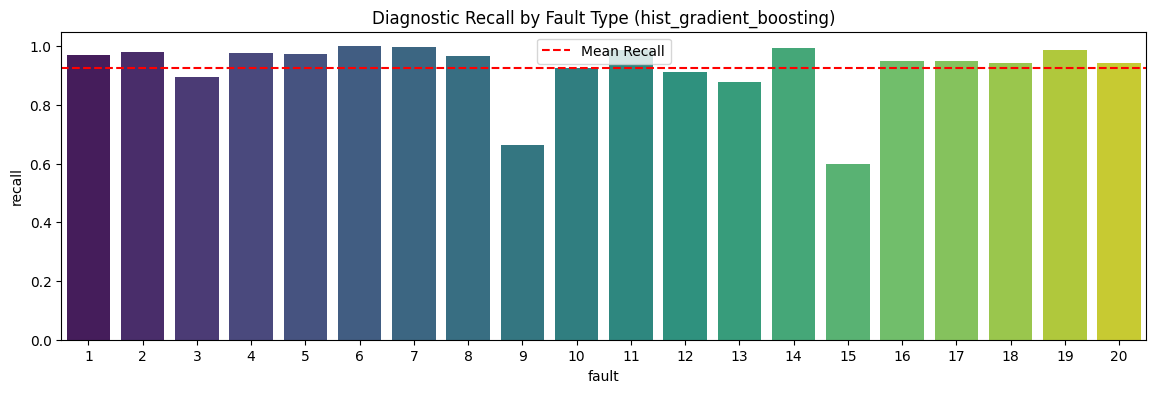

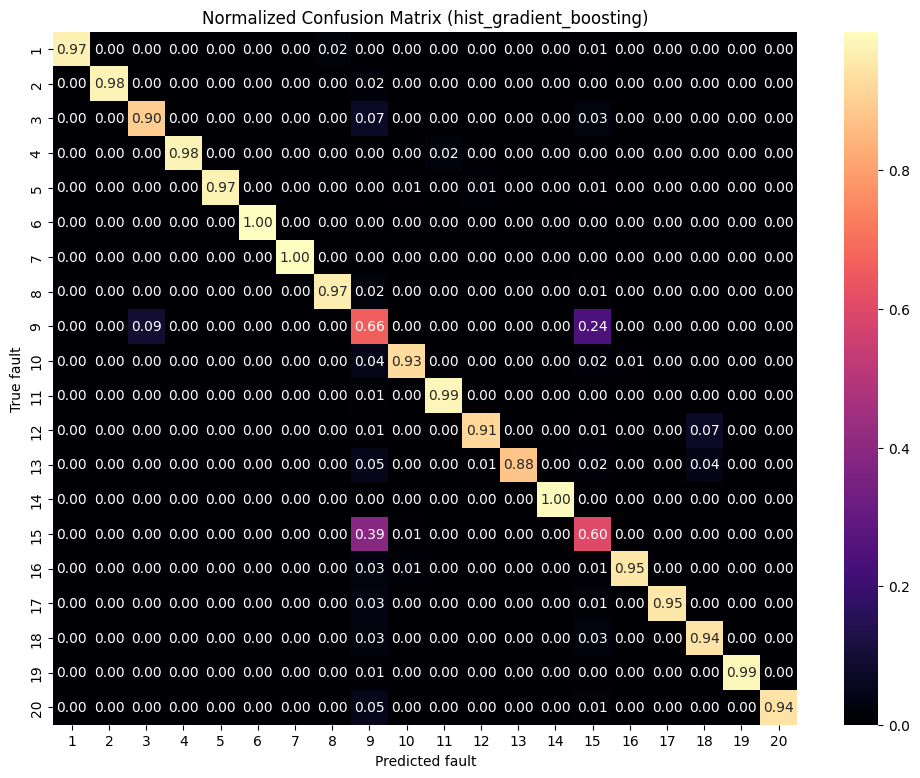

In [6]:
# Recall-by-class and confusion matrix for the selected champion.
champion_report = test_reports[champion_name]["classification_report"]
rep_df = pd.DataFrame(champion_report).transpose()
rep_df = rep_df.loc[rep_df.index.str.isnumeric()].copy()
rep_df["fault"] = rep_df.index.astype(int)

plt.figure(figsize=(14, 4))
sns.barplot(x=rep_df["fault"], y=rep_df["recall"], palette="viridis")
plt.axhline(rep_df["recall"].mean(), color="red", linestyle="--", label="Mean Recall")
plt.title(f"Diagnostic Recall by Fault Type ({champion_name})")
plt.ylim(0, 1.05)
plt.legend()
plt.show()

plt.figure(figsize=(12, 9))
sns.heatmap(
    test_reports[champion_name]["confusion_matrix"],
    annot=True,
    fmt=".2f",
    cmap="magma",
    xticklabels=labels,
    yticklabels=labels,
)
plt.title(f"Normalized Confusion Matrix ({champion_name})")
plt.xlabel("Predicted fault")
plt.ylabel("True fault")
plt.show()


In [ ]:
# -----------------------------------------------------------------
# Plot recall-by-class and normalized confusion matrices for all models
# Displays a 2-column grid: recall (left) and confusion matrix (right)
# for each evaluated model (no files are written).
# -----------------------------------------------------------------
models_to_plot = list(test_reports.keys())
num_models = len(models_to_plot)

fig, axes = plt.subplots(nrows=num_models, ncols=2, figsize=(14, 5 * max(1, num_models)))
if num_models == 1:
    axes = axes.reshape(1, 2)

for i, model_name in enumerate(models_to_plot):
    rep = pd.DataFrame(test_reports[model_name]["classification_report"]).transpose()
    rep = rep.loc[rep.index.str.isnumeric()].copy()
    rep["fault"] = rep.index.astype(int)

    ax_recall = axes[i, 0]
    sns.barplot(x=rep["fault"], y=rep["recall"], palette="viridis", ax=ax_recall)
    ax_recall.axhline(rep["recall"].mean(), color="red", linestyle="--", label="Mean Recall")
    ax_recall.set_title(f"{model_name} — Diagnostic Recall by Fault Type")
    ax_recall.set_ylim(0, 1.05)
    ax_recall.set_xlabel("Fault")
    ax_recall.set_ylabel("Recall")
    ax_recall.legend()

    ax_cm = axes[i, 1]
    sns.heatmap(
        test_reports[model_name]["confusion_matrix"],
        annot=True,
        fmt=".2f",
        cmap="magma",
        xticklabels=labels,
        yticklabels=labels,
        ax=ax_cm,
    )
    ax_cm.set_title(f"{model_name} — Normalized Confusion Matrix")
    ax_cm.set_xlabel("Predicted fault")
    ax_cm.set_ylabel("True fault")

plt.tight_layout()
plt.show()

In [7]:
# Save both models and comparison artifacts.
saved_model_paths = {}
for model_name, fitted in trained_models.items():
    model_path = MODEL_DIR / f"multiclass_{model_name}_w10_20_30_50_100.joblib"
    joblib.dump(fitted, model_path)
    saved_model_paths[model_name] = str(model_path)

artifacts = {
    "model_name": "multiclass_comparison",
    "champion": champion_name,
    "model_paths": saved_model_paths,
    "windows": CHAMPION_WINDOWS,
    "features": MODEL_FEATURE_COLS,
    "labels": labels,
    "comparison": full_comparison_df.to_dict(orient="records"),
    "reports": {
        name: result["classification_report"]
        for name, result in test_reports.items()
    },
    "confusion_matrices": {
        name: result["confusion_matrix"].tolist()
        for name, result in test_reports.items()
    },
}

artifact_path = MODEL_DIR / "multiclass_comparison_artifacts.json"
with artifact_path.open("w") as f:
    json.dump(artifacts, f)

comparison_path = OUTPUT_DIR / "multiclass_model_comparison.csv"
full_comparison_df.to_csv(comparison_path, index=False)

print(f"Saved models: {saved_model_paths}")
print(f"Artifacts saved to: {artifact_path}")
print(f"Comparison CSV saved to: {comparison_path}")


Saved models: {'hist_gradient_boosting': 'c:\\Users\\knowu\\Documents\\MSc AAI\\AIFI Group\\AIFI-group_project\\models\\final\\multiclass_hist_gradient_boosting_w10_20_30_50_100.joblib', 'xgboost': 'c:\\Users\\knowu\\Documents\\MSc AAI\\AIFI Group\\AIFI-group_project\\models\\final\\multiclass_xgboost_w10_20_30_50_100.joblib'}
Artifacts saved to: c:\Users\knowu\Documents\MSc AAI\AIFI Group\AIFI-group_project\models\final\multiclass_comparison_artifacts.json
Comparison CSV saved to: c:\Users\knowu\Documents\MSc AAI\AIFI Group\AIFI-group_project\outputs\multiclass_model_comparison.csv


In [ ]:
# Export probability-proxy outputs for presentation and downstream reporting.
# Run this cell after the full notebook has finished training/evaluating models.

def get_aligned_probabilities(model_name, fitted, X, target_labels):
    """Return predict_proba matrix aligned to target_labels order."""
    label_to_idx = {int(lbl): i for i, lbl in enumerate(target_labels)}

    if model_name == "xgboost":
        raw_probs = fitted["model"].predict_proba(X)
        model_labels = fitted["encoder"].inverse_transform(np.arange(raw_probs.shape[1]))
    else:
        raw_probs = fitted.predict_proba(X)
        model_labels = fitted.classes_

    aligned = np.zeros((X.shape[0], len(target_labels)), dtype=np.float32)
    for src_col, lbl in enumerate(model_labels):
        lbl = int(lbl)
        if lbl in label_to_idx:
            aligned[:, label_to_idx[lbl]] = raw_probs[:, src_col]
    return aligned


meta_cols = ["sample", "simulationRun", "original_fault_label", "target_fault_label"]
meta_base = test_eng[meta_cols].reset_index(drop=True).copy()
label_array = np.array(labels, dtype=int)

proxy_rows = []
champion_probs = None

for model_name, fitted in trained_models.items():
    probs = get_aligned_probabilities(model_name, fitted, X_test, labels)
    max_prob = probs.max(axis=1)
    pred_fault = label_array[probs.argmax(axis=1)]
    risk_proxy = 1.0 - max_prob

    out_df = meta_base.copy()
    out_df["model"] = model_name
    out_df["pred_fault"] = pred_fault
    out_df["max_prob"] = max_prob
    out_df["risk_proxy"] = risk_proxy
    proxy_rows.append(out_df)

    if model_name == champion_name:
        champion_probs = probs

proxy_df = pd.concat(proxy_rows, ignore_index=True)
proxy_path = OUTPUT_DIR / "multiclass_probability_proxy_summary.csv"
proxy_df.to_csv(proxy_path, index=False)

if champion_probs is not None:
    champion_prob_cols = {
        f"prob_fault_{lbl}": champion_probs[:, i]
        for i, lbl in enumerate(labels)
    }
    champion_prob_df = pd.concat(
        [meta_base, pd.DataFrame(champion_prob_cols)],
        axis=1,
    )
    champion_prob_df["pred_fault"] = label_array[champion_probs.argmax(axis=1)]
    champion_prob_df["max_prob"] = champion_probs.max(axis=1)
    champion_prob_df["risk_proxy"] = 1.0 - champion_prob_df["max_prob"]

    champion_path = OUTPUT_DIR / "multiclass_champion_probabilities.csv"
    champion_prob_df.to_csv(champion_path, index=False)
    print(f"Champion probability CSV saved to: {champion_path}")

print(f"Probability-proxy summary CSV saved to: {proxy_path}")
print("Done. Send these CSVs for reporting/presentation use.")

In [ ]:
# Time-series view of probability risk across one full run, including the pre-fault period.
# This shows how risk changes as the process moves from normal operation into fault development.

def get_aligned_probabilities(model_name, fitted, X, target_labels):
    label_to_idx = {int(lbl): i for i, lbl in enumerate(target_labels)}
    if model_name == "xgboost":
        raw_probs = fitted["model"].predict_proba(X)
        model_labels = fitted["encoder"].inverse_transform(np.arange(raw_probs.shape[1]))
    else:
        raw_probs = fitted.predict_proba(X)
        model_labels = fitted.classes_
    aligned = np.zeros((X.shape[0], len(target_labels)), dtype=np.float32)
    for src_col, lbl in enumerate(model_labels):
        lbl = int(lbl)
        if lbl in label_to_idx:
            aligned[:, label_to_idx[lbl]] = raw_probs[:, src_col]
    return aligned

# Pick a representative run that spans pre-fault and fault rows.
run_meta = test_eng_full.groupby("run_key").agg(
    min_sample=("sample", "min"),
    max_sample=("sample", "max"),
    fault_label=("original_fault_label", "first"),
).reset_index()
run_meta = run_meta[run_meta["fault_label"] > 0].copy()
run_meta = run_meta[run_meta["min_sample"] <= TEST_PREFAULT_CUTOFF]
if run_meta.empty:
    raise ValueError("No suitable test run found for the time-series risk plot.")

chosen_run_key = run_meta.sort_values(["max_sample", "min_sample"], ascending=[False, True]).iloc[0]["run_key"]
run_df = test_eng_full[test_eng_full["run_key"] == chosen_run_key].copy()
run_df = run_df.sort_values("sample").reset_index(drop=True)

champion_fitted = trained_models[champion_name]
run_probs = get_aligned_probabilities(
    champion_name,
    champion_fitted,
    run_df[MODEL_FEATURE_COLS].to_numpy(dtype=np.float32),
    labels,
 )
run_df["max_prob"] = run_probs.max(axis=1)
run_df["risk_proxy"] = 1.0 - run_df["max_prob"]
run_df["pred_fault"] = np.array(labels, dtype=int)[run_probs.argmax(axis=1)]

time_series_path = OUTPUT_DIR / f"multiclass_risk_timeseries_{champion_name}_run_{chosen_run_key}.csv"
run_export_cols = [
    "run_key",
    "sample",
    "simulationRun",
    "original_fault_label",
    "target_fault_label",
    "pred_fault",
    "max_prob",
    "risk_proxy",
]
run_df[run_export_cols].to_csv(time_series_path, index=False)
print(f"Risk time-series CSV saved to: {time_series_path}")

fault_onset_sample = int(run_df.loc[run_df["target_fault_label"] > 0, "sample"].min()) if (run_df["target_fault_label"] > 0).any() else None

fig, ax1 = plt.subplots(figsize=(14, 5))
ax1.plot(run_df["sample"], run_df["risk_proxy"], color="tab:red", linewidth=2.5, label="Risk proxy (1 - max probability)")
ax1.set_xlabel("Sample")
ax1.set_ylabel("Risk proxy", color="tab:red")
ax1.tick_params(axis="y", labelcolor="tab:red")
ax1.set_ylim(0, 1.05)
ax1.grid(True, alpha=0.25)

if fault_onset_sample is not None:
    ax1.axvline(fault_onset_sample, color="black", linestyle="--", linewidth=1.5, label="Fault onset")

ax2 = ax1.twinx()
ax2.plot(run_df["sample"], run_df["target_fault_label"], color="tab:blue", alpha=0.45, linewidth=2, label="True fault label")
ax2.set_ylabel("Fault label", color="tab:blue")
ax2.tick_params(axis="y", labelcolor="tab:blue")

title_fault = int(run_df["original_fault_label"].iloc[0])
plt.title(f"Risk proxy over time for a representative fault run (fault {title_fault}, {champion_name})")

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="upper left")
plt.tight_layout()
plt.show()

NameError: name 'test_eng_full' is not defined